<a href="https://colab.research.google.com/github/Astronom2617/rossmann-sales-forecasting/blob/main/rossmann_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train = pd.read_csv('/content/drive/MyDrive/rossmann/train.csv',
                    parse_dates=['Date'], low_memory=False)
store = pd.read_csv('/content/drive/MyDrive/rossmann/store.csv')
test = pd.read_csv('/content/drive/MyDrive/rossmann/test.csv',
                   parse_dates=['Date'])

In [3]:
train_df = train[train['Date'] < '2015-01-01']
test_df = train[train['Date'] >= '2015-01-01']

print(train_df.shape)
print(test_df.shape)

(780829, 9)
(236380, 9)


In [4]:
open_days_train_df = train_df[train_df['Open'] == 1]
open_days_train_df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
236380,1,3,2014-12-31,2605,327,1,0,0,1
236381,2,3,2014-12-31,2269,252,1,0,0,1
236382,3,3,2014-12-31,3804,408,1,0,0,1
236383,4,3,2014-12-31,10152,1311,1,0,0,1
236384,5,3,2014-12-31,1830,217,1,0,0,1
236385,6,3,2014-12-31,2604,308,1,0,0,1
236386,7,3,2014-12-31,5219,557,1,0,0,1
236387,8,3,2014-12-31,3025,394,1,0,0,1
236388,9,3,2014-12-31,5063,462,1,0,0,1
236389,10,3,2014-12-31,4216,450,1,0,0,1


In [5]:
avg_sales_for_each_store = train_df.groupby('Store')['Sales'].mean()
avg_sales_for_each_store.head(10)

,Sales
Store,
1,4006.230137
2,4115.884932
3,5755.087671
4,7978.980822
5,3872.182192
6,4740.336986
7,7330.567123
8,4427.346575
9,5195.217808


In [6]:
test_df['predicted'] = test_df['Store'].map(avg_sales_for_each_store)
test_df.head(10)

/tmp/ipykernel_7008/3194267932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted'] = test_df['Store'].map(avg_sales_for_each_store)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,predicted
0,1,5,2015-07-31,5263,555,1,1,0,1,4006.230137
1,2,5,2015-07-31,6064,625,1,1,0,1,4115.884932
2,3,5,2015-07-31,8314,821,1,1,0,1,5755.087671
3,4,5,2015-07-31,13995,1498,1,1,0,1,7978.980822
4,5,5,2015-07-31,4822,559,1,1,0,1,3872.182192
5,6,5,2015-07-31,5651,589,1,1,0,1,4740.336986
6,7,5,2015-07-31,15344,1414,1,1,0,1,7330.567123
7,8,5,2015-07-31,8492,833,1,1,0,1,4427.346575
8,9,5,2015-07-31,8565,687,1,1,0,1,5195.217808
9,10,5,2015-07-31,7185,681,1,1,0,1,4576.452055


In [8]:
RMSE_for_predict = np.sqrt(np.mean((test_df['predicted']-test_df['Sales'])**2))
print(RMSE_for_predict)

3267.9282445888903


### 1. Conclusion about RMSE
As we see, RMSE = €3267, which is a whopping 56% of the actual data, which is both good and bad. Good because it means the models we'll use have a higher chance of showing good results. Bad because it's a fairly large error.

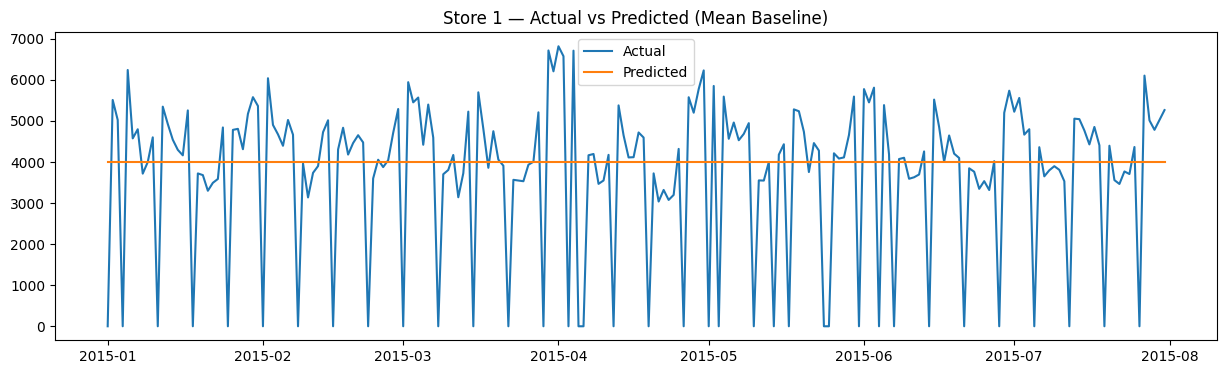

In [9]:
store1_test = test_df[test_df['Store'] == 1].sort_values('Date')

plt.figure(figsize=(15,4))
plt.plot(store1_test['Date'], store1_test['Sales'], label='Actual')
plt.plot(store1_test['Date'], store1_test['predicted'], label='Predicted')
plt.legend()
plt.title('Store 1 — Actual vs Predicted (Mean Baseline)')
plt.show()

### 2. Conclusion about Store 1 — Actual vs Predicted (Mean Baseline)
We see that the straight line doesn't capture seasonality, days of the week, or promotions. It's clear why the RMSE is 56%. Actual sales fluctuate, and our forecast isn't even close to reality. Baseline is a dumb proposition, but honestly.